# 1D Multiscale RM-CLEAN

Standard RM-CLEAN models the Faraday dispersion function (FDF) as a sum of delta functions convolved with the RMSF. That is ideal for Faraday-thin (point) sources, but a Faraday-thick source is genuinely extended in Faraday depth, and a pile of deltas is a poor model of it: the components form a spiky comb that overshoots the true envelope, even though the restored FDF looks fine once the beam smooths it over.

Multiscale RM-CLEAN is the RM-domain analogue of image-plane multiscale CLEAN (Cornwell 2008; Offringa & Smirnov 2017). Each component is a tapered kernel at one of several Faraday-depth *scales* (in units of the RMSF FWHM), not just a delta. What it buys you is a better *component model* of thick structure, and on thick sources it also tends to need fewer components: single-scale must build a deep comb of deltas to represent the width, while multiscale traces it with a handful of wide kernels. Every sub-minor iteration still places one component at a fixed gain, so the honest cost counter is `n_sub_minor_iter`.

Scale selection defaults to `multiscale_selection="hybrid"`: a source whose dirty peak fits at the width of the point response is cleaned exactly like single-scale CLEAN (point safety), while a genuinely wide peak lets matched-filter scoring choose among the extended scales. Turn the whole thing on with `multiscale=True`.

In [43]:
from __future__ import annotations

import logging

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import quantity_support
from rm_lite.tools_1d import rmclean, rmsynth
from rm_lite.utils.fitting import unit_centred_gaussian
from rm_lite.utils.logging import logger
from rm_lite.utils.simulate import build_model_fdf, delta, gauss, simulate_fdf, slab
from rm_lite.utils.synthesis import calc_faraday_moments

plt.rcParams["figure.dpi"] = 150
_ = quantity_support()
logger.setLevel(logging.WARNING)
rng = np.random.default_rng(42)

# A wide fractional bandwidth (300-1800 MHz) so extended Faraday structure
# survives depolarisation over several RMSF widths.
freqs = np.linspace(300, 1800, 300) * u.MHz
freq_hz = freqs.to(u.Hz).value
sigma_chan = 0.02  # per-channel noise in Q and U


def run_synth(complex_pol_arr):
    return rmsynth.run_rmsynth(
        freq_arr_hz=freq_hz,
        complex_pol_arr=complex_pol_arr,
        complex_pol_error=np.ones_like(complex_pol_arr)
        * (sigma_chan + 1j * sigma_chan),
        n_samples=50,
        phi_max_radm2=100,
    )

## Example 1: Faraday-thin source (point safety)

A thin source at RM = +3.3 RMSF FWHM. Multiscale must reproduce single-scale CLEAN here: same flux, same number of component-placement steps, all components on the delta scale at the source RM. The `simulate_fdf` helper forward-models the source through channel space, so the noise in the FDF is the physically correct correlated field.

In [27]:
thin_spec = delta(center_fwhm=3.3, amp=1.0)
sim_thin = simulate_fdf(thin_spec, freq_hz, rng=rng, sigma=sigma_chan)
synth_thin = run_synth(sim_thin.complex_pol_arr)

fwhm = float(synth_thin.fdf_parameters["fwhm_rmsf_radm2"][0])
rm_true = 3.3 * fwhm * u.rad / u.m**2
print(f"RMSF FWHM = {fwhm:.2f} rad/m2, source RM = {rm_true:.1f}")

WARNING rmsynth.run_rmsynth: Stokes I array/errors or model not provided. No fractional polarization will be calculated.


RMSF FWHM = 3.91 rad/m2, source RM = 12.9 rad / m2


In [28]:
help(rmclean.run_rmclean_from_synth)

Help on function run_rmclean_from_synth in module rm_lite.tools_1d.rmclean:

run_rmclean_from_synth(rm_synth_1d_results: 'RMSynth1DResults', auto_mask: 'float' = 7, auto_threshold: 'float' = 1, max_iter: 'int' = 10000, gain: 'float' = 0.1, mask_arr: 'NDArray[np.bool_] | None' = None, moment_threshold_snr: 'float' = 5.0, multiscale: 'bool' = False, multiscale_scale_bias: 'float' = 0.6, multiscale_scales: 'NDArray[np.float64] | None' = None, multiscale_n_scales: 'int | None' = None, multiscale_kernel: "Literal['tapered_quad', 'gaussian']" = 'tapered_quad', multiscale_max_iter_sub_minor: 'int' = 10000, multiscale_sub_minor_fraction: 'float' = 0.5, multiscale_selection: 'SelectionType' = 'hybrid', multiscale_selection_margin: 'float' = 0.08) -> 'RMClean1DResults'
    Run RM-CLEAN on the results of RM-synth.
    
    Args:
        rm_synth_1d_results (RMSynth1DResults): Results from RM-synth.
        auto_mask (float, optional): Masking threshold in SNR. Defaults to 7.
        auto_threshol

In [29]:
single_thin = rmclean.run_rmclean_from_synth(synth_thin, auto_mask=7, auto_threshold=1)
multi_thin = rmclean.run_rmclean_from_synth(
    synth_thin, auto_mask=7, auto_threshold=1, multiscale=True
)


def unpack(res):
    arrs = res.fdf_arrs
    params = res.clean_parameters
    return {
        "phi": arrs["phi_arr_radm2"].to_numpy() * u.rad / u.m**2,
        "dirty": arrs["fdf_dirty_complex_arr"].to_numpy().astype(complex),
        "clean": arrs["fdf_clean_complex_arr"].to_numpy().astype(complex),
        "model": arrs["fdf_model_complex_arr"].to_numpy().astype(complex),
        "resid": arrs["fdf_residual_complex_arr"].to_numpy().astype(complex),
        "mask": float(params["mask"][0]),
        "threshold": float(params["threshold"][0]),
        "n_iter": int(params["n_iter"][0]),
        "n_sub_minor_iter": int(params["n_sub_minor_iter"][0]),
    }


s = unpack(single_thin)
m = unpack(multi_thin)

WARNING clean.minor_loop: All channels masked. Exiting loop...performed 4 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 5 iterations


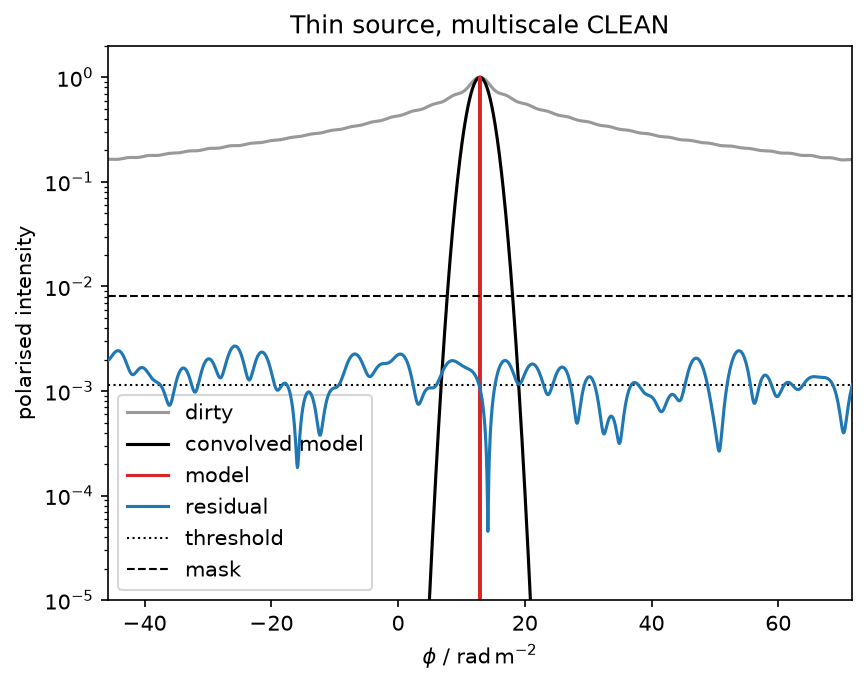

In [42]:
fig, ax = plt.subplots()
ax.plot(m["phi"], np.abs(m["dirty"]), color="k", alpha=0.4, label="dirty")
ax.plot(m["phi"], np.abs(m["clean"] - m["resid"]), color="k", alpha=1, label="convolved model")
ax.step(m["phi"], np.abs(m["model"]), color="tab:red", where="mid", label="model")
ax.plot(m["phi"], np.abs(m["resid"]), color="tab:blue", alpha=1, zorder=10, label="residual")
ax.axhline(m["threshold"], color="k", ls=":", label="threshold", lw=1)
ax.axhline(m["mask"], color="k", ls="--", label="mask", lw=1)
ax.set(
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="polarised intensity",
    title="Thin source, multiscale CLEAN",
    xlim=(rm_true.value - 15 * fwhm, rm_true.value + 15 * fwhm),
    yscale="log",
    ylim=(1e-5, 2e0)
)
ax.legend()

The component model is a handful of deltas at the source RM, exactly as single-scale would place them. The assertions below check the guarantees rather than describing them: the model flux matches single-scale, the components sit at the source RM, and the component-placement count is identical.

One counter subtlety: `n_iter` means different things in the two modes. For single-scale it counts components; for multiscale it counts *minor cycles* (scale re-selections), each of which can place many components. `n_sub_minor_iter` is the component count in both modes, so that is the number to compare.

In [6]:
# Components sit at the source RM.
support = np.abs(m["model"]) > 0
assert support.any()
assert np.all(np.abs(m["phi"][support] - rm_true) < 1.5 * fwhm * u.rad / u.m**2)

# Flux parity with single-scale.
m0_single = float(calc_faraday_moments(np.abs(s["clean"]), s["phi"].value, fwhm).mom0)
m0_multi = float(calc_faraday_moments(np.abs(m["clean"]), m["phi"].value, fwhm).mom0)
assert np.isclose(m0_single, m0_multi, rtol=1e-3)

# Identical work: same number of component placements.
assert m["n_sub_minor_iter"] == s["n_sub_minor_iter"]

print(f"flux: single {m0_single:.3f}, multi {m0_multi:.3f}")
print(
    f"components placed: single {s['n_sub_minor_iter']}, multi {m['n_sub_minor_iter']}"
)
print(f"multiscale minor cycles (scale re-selections): {m['n_iter']}")

flux: single 1.053, multi 1.052
components placed: single 65, multi 65
multiscale minor cycles (scale re-selections): 12


## Example 2: Faraday-thick source

An external-dispersion Gaussian with sigma = 1.5 RMSF FWHM. On this band such a source is still polarised over much of the band, so its width is genuinely recoverable.

This is where the two algorithms differ. Both recover the flux and both leave a comparable residual, but the *component models* are very different: single-scale builds a comb of deltas that overshoots the true envelope, while multiscale builds the source from wide kernels that trace it. The four panels show the input model and the clean models, bare and convolved with the clean beam. The beam hides the difference, which is exactly why the model matters: any physical interpretation of Faraday thickness uses the model, not the restored FDF.

Because single-scale has to represent the width with a deep comb of deltas, it also places far *more* components than multiscale, which traces the source with a few wide kernels. So on a thick source multiscale wins on both counts, model shape and component count, checked below.

In [51]:
thick_spec = gauss(1.5, amp=1.0)
sim_thick = simulate_fdf(thick_spec, freq_hz, rng=rng, sigma=sigma_chan)
synth_thick = run_synth(sim_thick.complex_pol_arr)

single_thick = rmclean.run_rmclean_from_synth(
    synth_thick, auto_mask=10, auto_threshold=1
)
multi_thick = rmclean.run_rmclean_from_synth(
    synth_thick, auto_mask=10, auto_threshold=1, multiscale=True
)
s = unpack(single_thick)
m = unpack(multi_thick)

phi = m["phi"].value
truth_model = build_model_fdf(thick_spec, phi, fwhm)

# Unit-peak clean beam, matching how rm_lite restores the model.
beam = unit_centred_gaussian(phi - phi[phi.size // 2], fwhm=fwhm)


def conv_beam(arr):
    return np.convolve(arr.real, beam, mode="same") + 1j * np.convolve(
        arr.imag, beam, mode="same"
    )

WARNING rmsynth.run_rmsynth: Stokes I array/errors or model not provided. No fractional polarization will be calculated.
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 11 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 1 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 10 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 7 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 209 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 48 iterations


[None, (0.0001, 0.2), Text(0.5, 0, '$\\phi$ / $\\mathrm{rad\\,m^{-2}}$')]

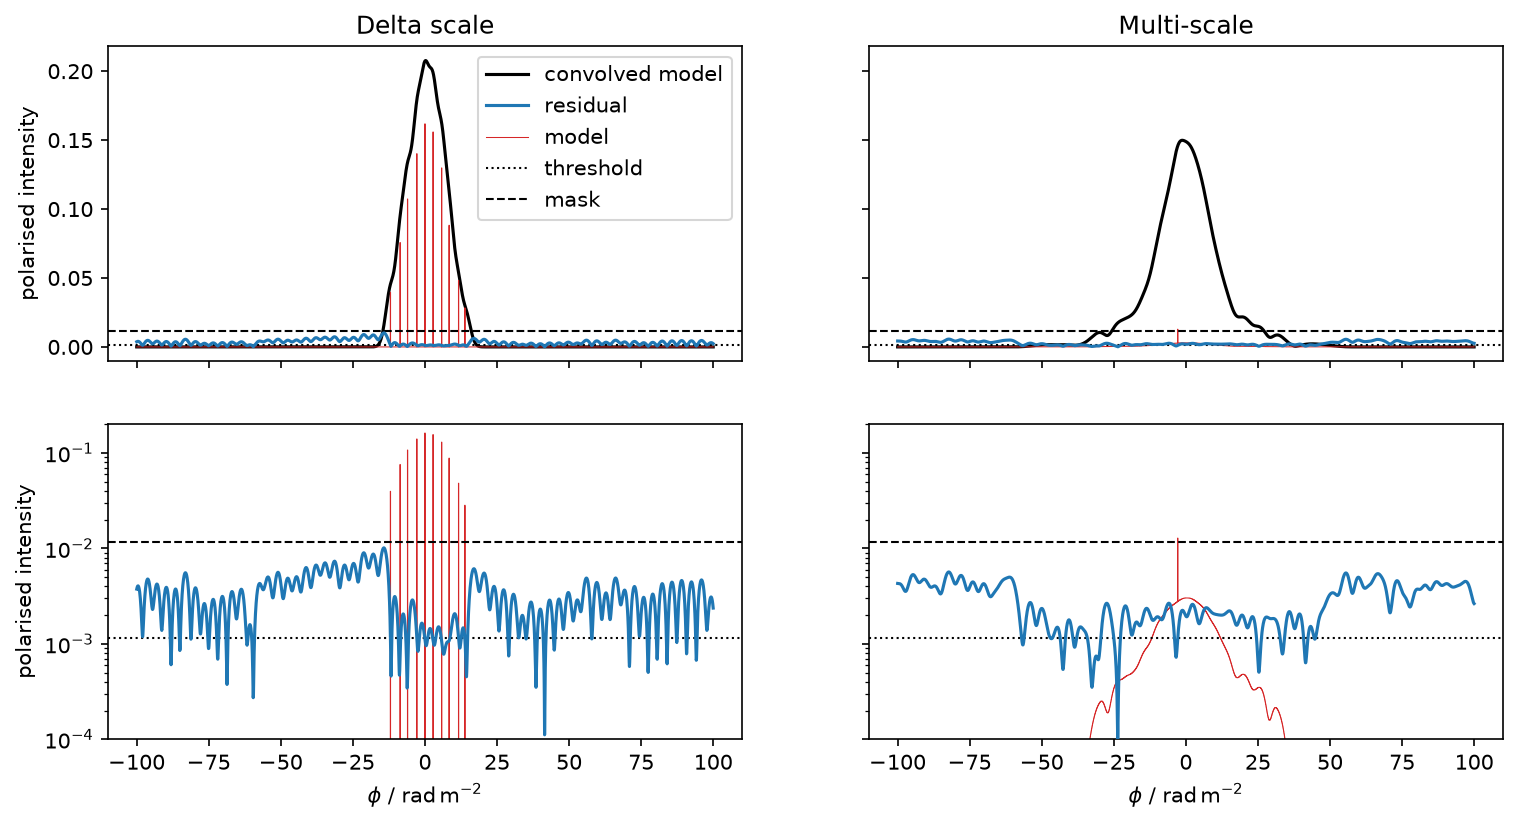

In [52]:
fig, axs = plt.subplots(2, 2, sharex="col", sharey="row", figsize=(12, 6))


axs[0, 0].plot(
    phi, np.abs(s["clean"] - s["resid"]), color="k", alpha=1, label="convolved model"
)
axs[0, 0].plot(
    phi, np.abs(s["resid"]), color="tab:blue", alpha=1, zorder=10, label="residual"
)
axs[0, 0].step(
    phi, np.abs(s["model"]), color="tab:red", where="mid", label="model", lw=0.5
)

axs[0, 0].axhline(m["threshold"], color="k", ls=":", label="threshold", lw=1)
axs[0, 0].axhline(m["mask"], color="k", ls="--", label="mask", lw=1)
axs[0, 0].legend()
axs[0, 0].set_title("Delta scale")
axs[0, 0].set(ylabel="polarised intensity")


axs[0, 1].plot(phi, np.abs(m["clean"] - m["resid"]), color="k", alpha=1)
axs[0, 1].plot(phi, np.abs(m["resid"]), color="tab:blue", alpha=1, zorder=10)
axs[0, 1].step(
    phi, np.abs(m["model"]), color="tab:red", where="mid", label="Single-scale", lw=0.5
)
axs[0, 1].axhline(m["threshold"], color="k", ls=":", label="Threshold", lw=1)
axs[0, 1].axhline(m["mask"], color="k", ls="--", label="Mask", lw=1)
axs[0, 1].set_title("Multi-scale")

axs[1, 0].plot(phi, np.abs(s["resid"]), color="tab:blue", zorder=10)
axs[1, 0].step(
    phi, np.abs(s["model"]), color="tab:red", where="mid", label="Single-scale", lw=0.5
)
axs[1, 0].axhline(m["threshold"], color="k", ls=":", label="Threshold", lw=1)
axs[1, 0].axhline(m["mask"], color="k", ls="--", label="Mask", lw=1)
axs[1, 0].set(ylabel="polarised intensity", xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}")

axs[1, 1].plot(phi, np.abs(m["resid"]), color="tab:blue", zorder=10)
axs[1, 1].step(
    phi, np.abs(m["model"]), color="tab:red", where="mid", label="Single-scale", lw=0.5
)
axs[1, 1].axhline(m["threshold"], color="k", ls=":", label="Threshold", lw=1)
axs[1, 1].axhline(m["mask"], color="k", ls="--", label="Mask", lw=1)
axs[1, 1].set(yscale="log", ylim=(1e-4, 2e-1), xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}")

In [9]:
def model_shape_error(model, truth):
    """Scale-free rms of |model| against best-fit-amplitude |truth|."""
    a, t = np.abs(model), np.abs(truth)
    amp = float((a * t).sum() / (t * t).sum())
    return float(np.sqrt(np.mean((a - amp * t) ** 2)) / (amp * t.max()))


err_single = model_shape_error(s["model"], truth_model)
err_multi = model_shape_error(m["model"], truth_model)
print(
    f"model shape error: single {err_single:.3f}, multi {err_multi:.3f} "
    f"(ratio {err_multi / err_single:.2f})"
)

# The multiscale model is much closer to the true envelope.
assert err_multi < 0.5 * err_single

# At no cost in flux ...
m0_single = float(calc_faraday_moments(np.abs(s["clean"]), phi, fwhm).mom0)
m0_multi = float(calc_faraday_moments(np.abs(m["clean"]), phi, fwhm).mom0)
assert 0.9 < m0_multi / m0_single < 1.2

# ... and with fewer components: single-scale needs a deep comb of deltas to
# represent the width, while multiscale traces it with a handful of wide kernels.
steps_ratio = m["n_sub_minor_iter"] / s["n_sub_minor_iter"]
assert steps_ratio < 1.0
print(f"flux: single {m0_single:.3f}, multi {m0_multi:.3f}")
print(
    f"components placed: single {s['n_sub_minor_iter']}, multi {m['n_sub_minor_iter']} "
    f"(ratio {steps_ratio:.2f})"
)

model shape error: single 1.381, multi 0.075 (ratio 0.05)
flux: single 0.967, multi 0.998
components placed: single 4142, multi 628 (ratio 0.15)


## Example 3: narrow bands degenerate to single-scale

The scales are in units of the RMSF FWHM, and the largest recoverable Faraday scale is set by the shortest wavelength in the band: `phi_max_scale = pi / lambda_sq_min`. On a narrow band the RMSF is so wide that no extended scale fits below that ceiling, so the automatic grid collapses to `[0.0]` (with a warning) and multiscale CLEAN is exactly single-scale CLEAN. This is safe, and it is also physics: a source wider than the ceiling is depolarised out of the band, so there is nothing for a wide kernel to recover.

In [10]:
from rm_lite.utils.clean import MultiscaleOptions, default_scales
from rm_lite.utils.synthesis import freq_to_lambda2, get_fwhm_rmsf, make_phi_arr

narrow_hz = np.linspace(744e6, 1032e6, 288)  # RACS-low band
lam2 = freq_to_lambda2(narrow_hz)
narrow_fwhm = float(get_fwhm_rmsf(lam2).fwhm_rmsf_radm2)
phi_max_scale = float(np.pi / lam2.min())
phi_narrow = make_phi_arr(500.0, narrow_fwhm / 10)

grid = default_scales(
    phi_narrow, narrow_fwhm, MultiscaleOptions(), phi_max_scale_radm2=phi_max_scale
)
print(f"RMSF FWHM = {narrow_fwhm:.1f} rad/m2")
print(
    f"largest recoverable scale = {phi_max_scale:.1f} rad/m2 "
    f"= {phi_max_scale / narrow_fwhm:.2f} FWHM"
)
print(f"auto scale grid (FWHM units): {grid}")

# No extended scale fits below the ceiling: the grid is delta-only.
assert grid.tolist() == [0.0]

WARNING clean.default_scales: Multiscale auto grid degenerated to [0.0]: the phi window is narrower than 2*first_scale*RMSF FWHM (292 rad/m^2), so no extended scale fits and multiscale CLEAN reduces to single-scale. Pass explicit `multiscale_scales` to force an extended grid.


RMSF FWHM = 48.7 rad/m2
largest recoverable scale = 37.2 rad/m2 = 0.76 FWHM
auto scale grid (FWHM units): [0.]


In [11]:
# And the clean itself is identical to single-scale, at identical cost.
sim_narrow = simulate_fdf(thin_spec, narrow_hz, rng=rng, sigma=sigma_chan)
synth_narrow = rmsynth.run_rmsynth(
    freq_arr_hz=narrow_hz,
    complex_pol_arr=sim_narrow.complex_pol_arr,
    complex_pol_error=np.ones_like(sim_narrow.complex_pol_arr)
    * (sigma_chan + 1j * sigma_chan),
    n_samples=50,
)
single_n = unpack(
    rmclean.run_rmclean_from_synth(synth_narrow, auto_mask=7, auto_threshold=1)
)
multi_n = unpack(
    rmclean.run_rmclean_from_synth(
        synth_narrow, auto_mask=7, auto_threshold=1, multiscale=True
    )
)
assert np.allclose(single_n["clean"], multi_n["clean"])
assert single_n["n_sub_minor_iter"] == multi_n["n_sub_minor_iter"]
print(
    "narrowband multiscale == single-scale, "
    f"{multi_n['n_sub_minor_iter']} components each"
)

WARNING rmsynth.run_rmsynth: Stokes I array/errors or model not provided. No fractional polarization will be calculated.
WARNING clean.default_scales: Multiscale auto grid degenerated to [0.0]: the phi window is narrower than 2*first_scale*RMSF FWHM (292 rad/m^2), so no extended scale fits and multiscale CLEAN reduces to single-scale. Pass explicit `multiscale_scales` to force an extended grid.


narrowband multiscale == single-scale, 68 components each


### The escape hatch: forcing your own scales

`multiscale_scales` overrides the automatic grid. The legitimate use is on a band that *does* support extended structure, when you want a leaner grid than the automatic one. Forcing extended scales onto a narrow band cannot beat the depolarisation ceiling: the "hybrid" selector will classify what little it sees as beam-width and clean it single-scale anyway.

One caution: a bigger scale is not a better scale. Under the correlated noise of the FDF the matched-filter score of a very wide kernel never competes with the delta scale, so forcing a grid like `[0, 8]` just disengages multiscale. The scale the automatic run actually engages on this source is 3, so the leaner grid worth forcing is `[0, 3]`. The model win survives with it.

In [12]:
multi_forced = unpack(
    rmclean.run_rmclean_from_synth(
        synth_thick,
        auto_mask=10,
        auto_threshold=1,
        multiscale=True,
        multiscale_scales=np.array([0.0, 3.0]),
    )
)
err_forced = model_shape_error(multi_forced["model"], truth_model)
print(
    f"model shape error with forced grid [0, 3]: {err_forced:.3f} "
    f"(single-scale {err_single:.3f})"
)
assert err_forced < 0.7 * err_single

# Flux is still consistent with single-scale.
m0_forced = float(calc_faraday_moments(np.abs(multi_forced["clean"]), phi, fwhm).mom0)
assert 0.9 < m0_forced / m0_single < 1.2

WARNING clean.minor_loop: All channels masked. Exiting loop...performed 10 iterations
WARNING clean.minor_loop: All channels masked. Exiting loop...performed 60 iterations


model shape error with forced grid [0, 3]: 0.077 (single-scale 1.381)


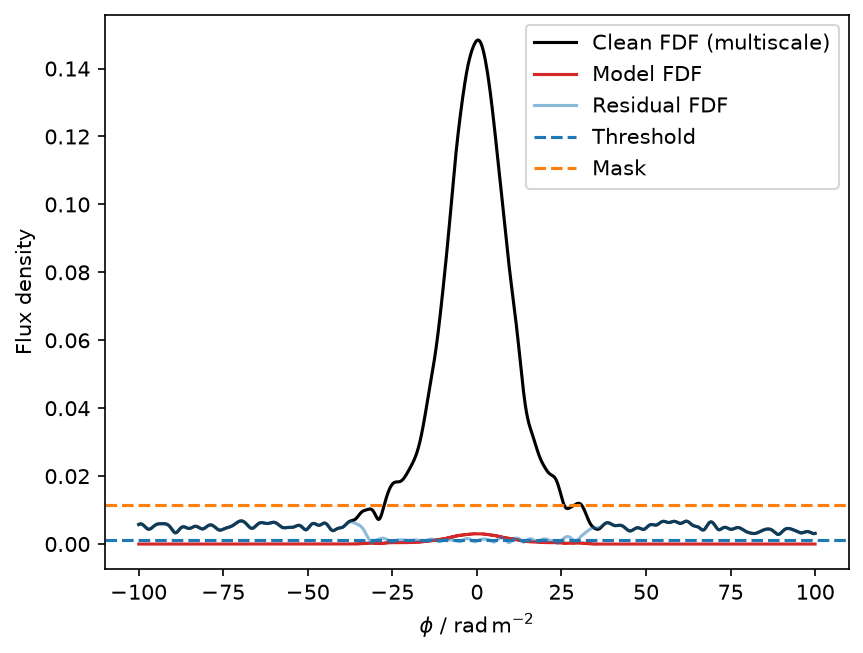

In [14]:
fig, ax = plt.subplots()
ax.plot(
    multi_forced["phi"],
    np.abs(multi_forced["clean"]),
    color="k",
    label="Clean FDF (multiscale)",
)
ax.step(
    multi_forced["phi"],
    np.abs(multi_forced["model"]),
    color="tab:red",
    where="mid",
    label="Model FDF",
)
ax.plot(
    multi_forced["phi"],
    np.abs(multi_forced["resid"]),
    color="tab:blue",
    alpha=0.5,
    label="Residual FDF",
)
ax.axhline(multi_forced["threshold"], color="tab:blue", ls="--", label="Threshold")
ax.axhline(multi_forced["mask"], color="tab:orange", ls="--", label="Mask")
ax.set(
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="Flux density",
    # yscale="log",
)
ax.legend()

## Summary

- `multiscale=True` is safe to leave on: thin sources are cleaned exactly like single-scale CLEAN, and narrow bands degenerate to single-scale by construction.
- The win is the *component model* of Faraday-thick structure; on thick sources multiscale also places far fewer components than single-scale, which needs a deep delta comb. Compare costs with `n_sub_minor_iter`; `n_iter` counts scale re-selections in multiscale mode.
- The largest recoverable Faraday scale is `pi / lambda_sq_min`. Wider structure is depolarised out of the band and no algorithm can recover it.
- `multiscale_scales` forces a custom grid (in RMSF FWHM units); it cannot beat the depolarisation ceiling, and very wide scales simply disengage.